# All imports

In [7]:
%load_ext autoreload
%autoreload 2

# Set up GPU rendering.
import os
import subprocess
import warnings

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl
import mujoco

# Other imports and helper functions
import time
import itertools
import numpy as np
from copy import deepcopy
import json as _json

from scipy.optimize import curve_fit, fsolve
from scipy.signal import medfilt
from scipy.stats import linregress

from mujoco_irb120.common.load_obj_in_env import load_environment, load_photoshoot
from mujoco_irb120.common.com_estimation import get_AdT_sensor_O, model_bkwd_wrench, model_fwd_wrench, align_zeros
from mujoco_irb120.common.plotting_helper import plot_wrench_and_tipping
from mujoco_irb120.common.trajectory_recorder import TrajectoryRecorder
import mujoco_irb120.common.robot_controller as robot_controller
from mujoco_irb120.common.helper_fns import *
from mujoco_irb120.common.render_opts import RendererViewerOpts

# Graphics and plotting.
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import contextlib

from scipy.signal import butter, filtfilt
from scipy.spatial.transform import Rotation as Robj

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)
# Set matplotlib font size
fonts = {'size' : 20}
plt.rc('font', **fonts)
%matplotlib inline
# %matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl


#### (Optional) Keyboard Cartesian Control Setup
To enable interactive keyboard control of the robot end-effector:
- **Arrow Keys**: Move in X and Z directions
  - LEFT: Move -X (away from object)
  - RIGHT: Move +X (toward object)
  - UP: Move +Z (lift)
  - DOWN: Move -Z (lower)

Set `KEYBOARD_CONTROL = True` below to enable. Requires `VIZ = True` and focus on the viewer window.

In [8]:
# Enable/disable keyboard control toggle
KEYBOARD_CONTROL = True   # Set to False to disable keyboard control
print(f"Keyboard control: {'ENABLED' if KEYBOARD_CONTROL else 'DISABLED'}")
if KEYBOARD_CONTROL:
    print("  Controls: Arrow keys to move in X and Z directions")
    print("  Make sure viewer window has focus for keyboard input")

Keyboard control: ENABLED
  Controls: Arrow keys to move in X and Z directions
  Make sure viewer window has focus for keyboard input


## Main Simulation Loop

In [15]:
# ======================== Toggle visualization here =========================
VIZ = True   # set to False to record video without showing the viewer
MOTION_MODE = 'PLAYBACK'   # Set to 'RECORD' to record keyboard motion, 'PLAYBACK' to replay from recorded_motion.npz
RECORD_FORCES = True   # Set to True to also record F/T sensor data during manual control
# ============================================================================

## Let's recall the model to reset the simulation
# 0: box_exp, 10: heart, 11: L_shape, 12: monitor, 13: soda, 14: flashlight
OBJECT = 0

model, data = load_environment(num=OBJECT, launch_viewer=False)

## =================== LOAD GROUND TRUTH PARAMS FROM JSON ===================
_obj_params = _json.load(open("object_params.json"))["objects"][str(OBJECT)]

com_gt   = np.subtract(_obj_params["com_gt_onshape"], _obj_params["com_gt_offset"])
m_gt     = _obj_params["mass_gt"]
init_xyz = np.array(_obj_params["init_xyz"])
## ===================================================================

## =================== SET FRICTION AT RUNTIME ===================
MU_TABLE = 0.2   # object-table sliding friction (override here to test different regimes)
model.geom_friction[model.geom("table").id, 0] = MU_TABLE

# Effective frictions for reference:
mu_obj        = model.geom_friction[model.ngeom - 1, 0]  # object geom sliding friction
mu_gt         = np.sqrt(MU_TABLE * mu_obj)               # effective object-table contact friction
mu_finger_obj = np.sqrt(model.geom_friction[model.geom("push_rod").id, 0] * mu_obj)  # effective finger-object
print(f"Table friction set to: {MU_TABLE}")
print(f"Effective object-table mu: {mu_gt:.3f}")
print(f"Effective finger-object mu: {mu_finger_obj:.3f}")
## ================================================================

## Setup based on robot model
irb = robot_controller.controller(model, data)

# Get initial EE pose (finger tip)
T_home = irb.FK()
print('Initial end-effector pose:\n', T_home)

## Set robot just in front of payload (same orientation as home position (facing +x))
T_init = T_home.copy()
T_init[:3, 3] = init_xyz.copy()

q_init = irb.IK(T_init, method=2, damping=0.5, max_iters=1000) # DLS method
irb.set_pose(q=q_init)

## The end pose we want to reach FOR POSITION CONTROL (format: 4x4 matrix)
T_end = T_init.copy()
T_end[0, 3] += 0.10  # Move EE forward by 15 cm in x direction

target_q = irb.IK(T_end, method=2, damping=0.5, max_iters=1000)  # DLS method

## TARE / Bias sensor
irb.ft_bias(n_samples=200)

## FOR VELOCITY CONTROL (format: [wx wy wz vx vy vz])
# target_vel  = np.array([0.0, 0.0, 0.0, 0.14, 0.0, 0.0])  # Move EE forward at 4 cm/s in x direction

## Initialize time, force and tilt history for plotting
t_hist          = []
w_hist          = []
quat_hist       = []
ball_pose_hist  = []  # (4,4) pose of ball-center site in world frame
sens_pose_hist  = []  # (4,4) pose of FT sensor site in world frame
con_bool_hist   = []  # contact flag
obj_pose_hist   = []  # (4,4) object pose in world frame (mj internal)

traj_duration = 6.0 # seconds
run_duration = traj_duration + 50.0 # 4.0  # seconds

# Initialize trajectory recorder for recording or load trajectory for playback
recorder = None
loaded_trajectory = None

if MOTION_MODE == 'RECORD':
    recorder = TrajectoryRecorder(irb)
    recorder.start_recording(verbose=False, record_forces=RECORD_FORCES)
elif MOTION_MODE == 'PLAYBACK':
    recorder = TrajectoryRecorder(irb)
    try:
        loaded_trajectory = recorder.load_trajectory("recorded_motion.npz")
        recorder.start_playback(trajectory=loaded_trajectory)
        print("Loaded and ready for playback.")
    except FileNotFoundError:
        print("ERROR: recorded_motion.npz not found. Skipping playback.")
        MOTION_MODE = None

## Additions for video recording
rv = RendererViewerOpts(model, data, vis=VIZ, show_left_UI=True)
# ===========================================================================
with rv: # enters viewer if vis=True, sets viewer opts, and readies offscreen renderer for video capture
    while rv.viewer_is_running() and not irb.stop and data.time < run_duration:
        irb.check_topple()                          # Check for payload topple condition

        # Apply control: either keyboard-based or trajectory-based position control
        if KEYBOARD_CONTROL and VIZ:
            v_cmd = rv.get_keyboard_input()
            irb.apply_cartesian_keyboard_ctrl(v_cmd, maintain_orientation=True, verbose=False)
        else:
            if data.time < traj_duration:
                alpha = data.time / traj_duration
                interp_q = (1 - alpha) * q_init + alpha * target_q
            else:
                interp_q = target_q.copy()
            irb.set_pos_ctrl(interp_q, check_ellipsoid=False)

        # Record or playback waypoint if enabled
        if MOTION_MODE == 'RECORD' and recorder:
            recorder.record_waypoint(record_type='joints')
        elif MOTION_MODE == 'PLAYBACK' and recorder:
            recorder.playback_step(playback_type='joints', interpolate=True)

        mujoco.mj_step(model, data)                 # Step the simulation

        w_hist.append(irb.ft_get_reading())
        quat_hist.append(irb.get_payload_pose(out='quat'))
        t_hist.append(data.time)
        ball_pose_hist.append(irb.ball_pose)
        sens_pose_hist.append(irb.sensor_pose)
        con_bool_hist.append(irb.check_contact())
        obj_pose_hist.append(irb.get_payload_pose(out='T'))

        rv.sync()
        rv.capture_frame_if_due(data)

t_hist          = np.asarray(t_hist,         dtype=float)
quat_hist       = np.asarray(quat_hist,      dtype=float)
con_bool_hist   = np.asarray(con_bool_hist,  dtype=float)
w_hist          = np.asarray(w_hist,         dtype=float).reshape(-1, 6)
ball_pose_hist  = np.asarray(ball_pose_hist, dtype=float).reshape(-1, 4, 4)
sens_pose_hist  = np.asarray(sens_pose_hist, dtype=float).reshape(-1, 4, 4)
obj_pose_hist   = np.asarray(obj_pose_hist,  dtype=float).reshape(-1, 4, 4)

ball_pos_hist = ball_pose_hist[:, :3, 3]
sens_pos_hist = sens_pose_hist[:, :3, 3]
obj_pos_hist  = obj_pose_hist[:,  :3, 3]

# Save trajectory if recording was enabled (skip if playback mode)
if MOTION_MODE == 'RECORD' and recorder:
    recorder.stop_recording(verbose=False)
    recorder.save_trajectory("recorded_motion.npz", format='numpy')
elif MOTION_MODE == 'PLAYBACK' and recorder:
    recorder.stop_playback()

print(f'\nSimulation ended in t = {data.time:.2f} seconds.')
media.show_video(rv.frames, fps=rv.framerate)

Table friction set to: 0.2
Effective object-table mu: 0.000
Effective finger-object mu: 0.000
Initial end-effector pose:
 [[1.    0.    0.    0.374]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.665]
 [0.    0.    0.    1.   ]]
Biasing F/T sensor with 200 static samples...
Force offset: [-0.    -1.256  0.     0.089 -0.    -0.   ]
[RECORDER] Loaded trajectory from recorded_motion.npz (numpy format)
  - Waypoints: 3718
  - Duration: 3.72 s
  - With force data
[RECORDER] Started playback of 3718 waypoints over 3.72 seconds.
Loaded and ready for playback.
[RECORDER] Stopped trajectory playback.

Simulation ended in t = 8.07 seconds.


This browser does not support the video tag.


In [17]:
# # ====== WORKAROUND: Save all simulation variables to numpy file ======
# # This captures all the data collected during the simulation loop
# # Useful when you want to preserve force/pose history even if not using trajectory recorder

# np.savez(
#     "simulation_data.npz",
#     t_hist=t_hist,
#     w_hist=w_hist,                    # Force/torque at each step (N, Nm)
#     quat_hist=quat_hist,              # Object quaternion at each step
#     ball_pose_hist=ball_pose_hist,    # Ball-center pose (4x4 transforms)
#     sens_pose_hist=sens_pose_hist,    # FT sensor pose (4x4 transforms)
#     con_bool_hist=con_bool_hist,      # Contact status at each step
#     obj_pose_hist=obj_pose_hist,      # Object pose (4x4 transforms)
#     ball_pos_hist=ball_pos_hist,      # Ball position trajectory
#     sens_pos_hist=sens_pos_hist,      # Sensor position trajectory
#     obj_pos_hist=obj_pos_hist         # Object position trajectory
# )
# print("Saved all simulation data to simulation_data.npz")

# LOAD DATA HERE:
sim_data = np.load("simulation_data.npz")

# Extract all variables from the saved file
t_hist = sim_data['t_hist']
w_hist = sim_data['w_hist']
quat_hist = sim_data['quat_hist']
ball_pose_hist = sim_data['ball_pose_hist']
sens_pose_hist = sim_data['sens_pose_hist']
con_bool_hist = sim_data['con_bool_hist']
obj_pose_hist = sim_data['obj_pose_hist']
ball_pos_hist = sim_data['ball_pos_hist']
sens_pos_hist = sim_data['sens_pos_hist']
obj_pos_hist = sim_data['obj_pos_hist']

print(f"Loaded simulation data ({len(t_hist)} timesteps)")
print(f"  Time range: {t_hist[0]:.2f} to {t_hist[-1]:.2f} s")
print(f"  Force data shape: {w_hist.shape}")
print(f"  Object position range: {obj_pos_hist.min(axis=0)} to {obj_pos_hist.max(axis=0)}")

Loaded simulation data (3851 timesteps)
  Time range: 0.25 to 4.10 s
  Force data shape: (3851, 6)
  Object position range: [ 0.586 -0.     0.2  ] to [0.62  0.    0.207]


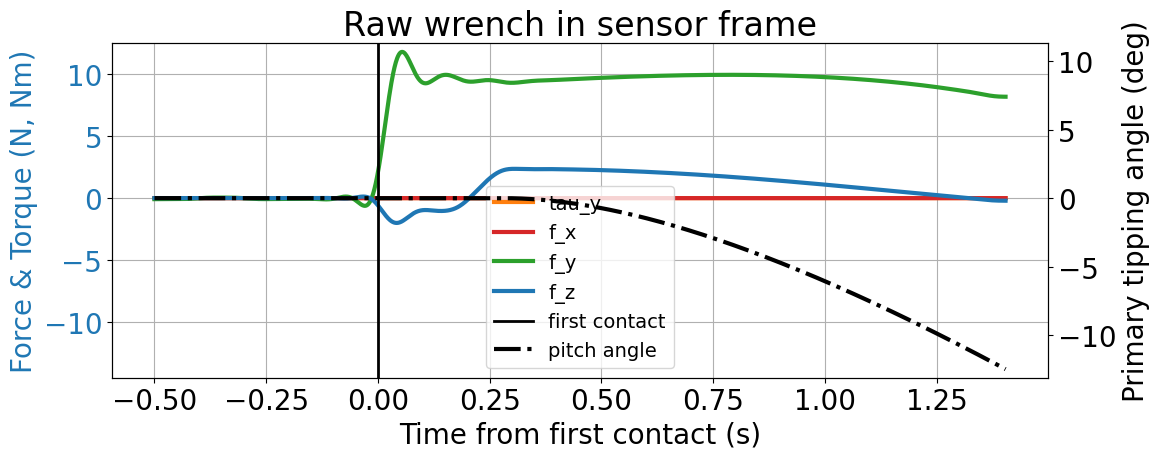

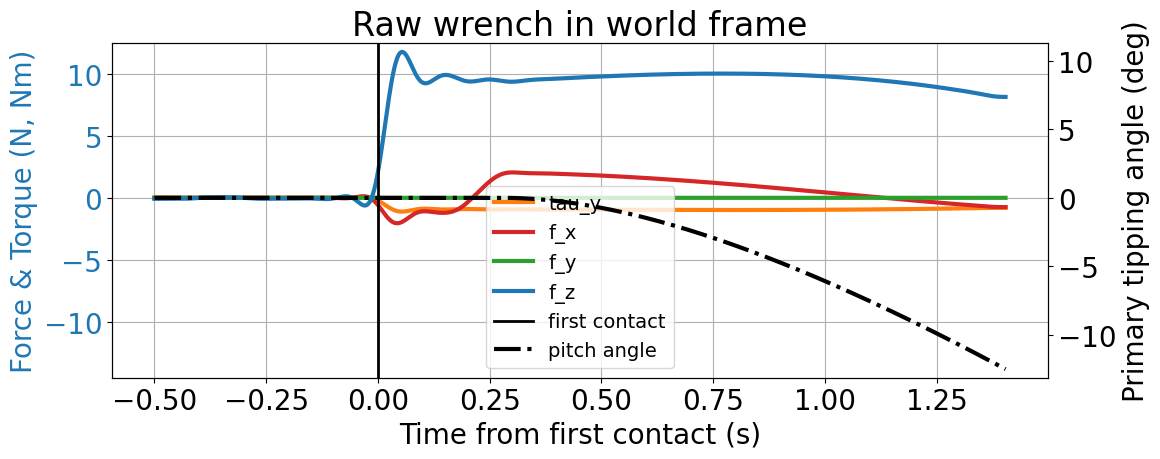

In [18]:
# Plot primary torque axis and primary tipping angle from 0.5 s before first contact
contact_mask = np.asarray(con_bool_hist).reshape(-1) > 0.5
if not np.any(contact_mask):
    warnings.warn("No contact detected, showing all data.")

first_contact_idx = int(np.argmax(contact_mask))
first_contact_time = float(t_hist[first_contact_idx])
window_start_time = max(float(t_hist[0]), first_contact_time - 0.5)
window_mask = t_hist >= window_start_time

# Filter wrench history in sensor frame {S}, then rotate to world/base frame {B}.
b, a = butter(4, 6, fs=500, btype='low')
w_meas_filt = filtfilt(b, a, w_hist, axis=0)   # (N,6) filtered, still in {S}

# UNCOMMENT TO USE RAW DATA
# w_meas_filt = w_hist.copy()

## TRIM TO CONTACT WINDOW
t_window    = t_hist[window_mask] - first_contact_time
w_S_meas    = w_meas_filt[window_mask, :]  # (N,6) in {B}, force on object
# Convert quaternion history to primary tipping angle (pitch)
quat_B      = quat_hist[window_mask, :]
pitch_B     = Robj.from_quat(quat_B).as_euler('xyz', degrees=False)[:, 1]
# Object pose, sensor pose, ball pose - all (N,4,4)
T_B_obj     = obj_pose_hist[window_mask,  :, :]
T_B_sensor  = sens_pose_hist[window_mask, :, :]
T_B_ball    = ball_pose_hist[window_mask, :, :]
p_B_ee      = T_B_ball[:, :3, 3]   # (N,3) fingertip position in world

# --- Rotate {S} -> {B} ---
_R_BS = T_B_sensor[:, :3, :3]                    # (N,3,3) Sensor orientation in world frame, i.e., rotation from sensor frame {S} to world/base frame {B}
w_B_meas = np.concatenate([
    np.einsum('nij,nj->ni', _R_BS, w_S_meas[:, :3]),
    np.einsum('nij,nj->ni', _R_BS, w_S_meas[:, 3:]),
], axis=1)                                             # (N,6) in {B}, force on object


# Reusable plot style for wrench + pitch
fig, ax1, ax2 = plot_wrench_and_tipping(
    t=t_window,
    force_xyz=w_S_meas[:, :3],
    torque_primary=w_S_meas[:, 4],
    pitch_rad=pitch_B,
    torque_label='tau_y',
    force_labels=('f_x', 'f_y', 'f_z'),
    y_label='Force & Torque (N, Nm)',
    title='Raw wrench in sensor frame',
)

## Plot the world wrench
fig, ax1, ax2 = plot_wrench_and_tipping(
    t=t_window,
    force_xyz=w_B_meas[:, :3],
    torque_primary=w_B_meas[:, 4],
    pitch_rad=pitch_B,
    torque_label='tau_y',
    force_labels=('f_x', 'f_y', 'f_z'),
    y_label='Force & Torque (N, Nm)',
    title='Raw wrench in world frame',
)

**Model fitting! Steps:**
1. Compute applied wrench from measured wrench
2. Fit curve comparing expected to applied wrench

Measured wrench {S} at first 5 contact:
 [[ 0.    -0.083  0.005  0.003  0.     0.   ]
 [ 0.    -0.083  0.005  0.003  0.     0.   ]
 [ 0.    -0.082  0.005  0.003  0.     0.   ]
 [ 0.    -0.082  0.005  0.003  0.     0.   ]
 [ 0.    -0.082  0.005  0.003  0.     0.   ]]
Measured wrench {B} at first 5 contact:
 [[ 0.005  0.    -0.083  0.     0.003  0.   ]
 [ 0.005  0.    -0.083  0.     0.003  0.   ]
 [ 0.005  0.    -0.082  0.     0.003  0.   ]
 [ 0.005  0.    -0.082  0.     0.003  0.   ]
 [ 0.005  0.    -0.082  0.     0.003  0.   ]]
Applied wrench {O} at first 5 contact:
 [[-0.005 -0.     0.083  0.     0.001  0.   ]
 [-0.005 -0.     0.083  0.     0.001  0.   ]
 [-0.005 -0.     0.082  0.     0.001  0.   ]
 [-0.005 -0.     0.082  0.     0.001  0.   ]
 [-0.005 -0.     0.082  0.     0.001  0.   ]]
Finger pos in object frame:
 [[-0.024  0.     0.184]
 [-0.024  0.     0.184]
 [-0.024  0.     0.184]
 [-0.024  0.     0.184]
 [-0.024  0.     0.184]]


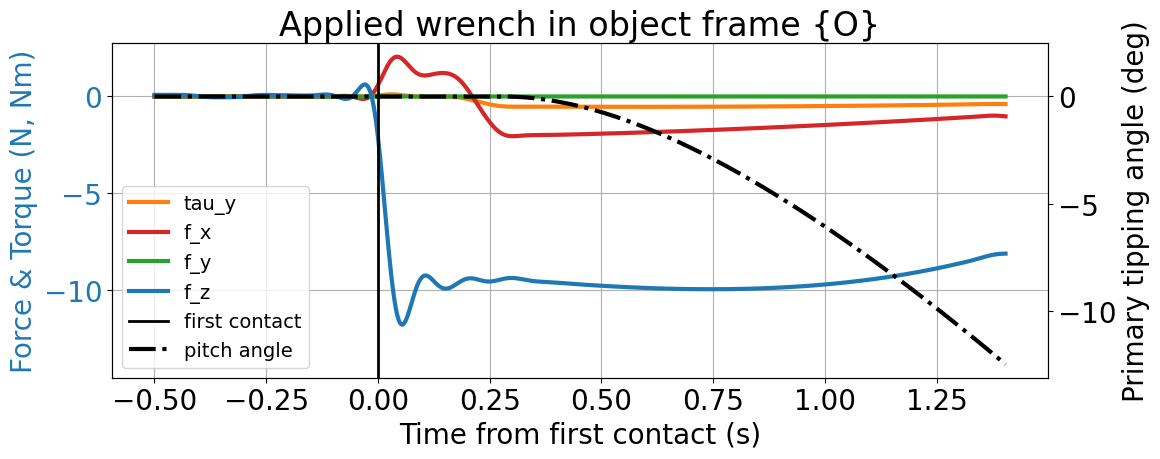

In [24]:
# Frames:
#   {B} = world/base frame
#   {S} = FT sensor frame  (site:sensor)
#   {O} = object frame     (site:obj_frame_site / payload_site) 

# 1. AdT needed for backward wrench projection from sensor to object frame.
#  1a. AdT takes in:
#   I.   Object rotation vectors in world/robot/base frame
#   II.  Position of sensor in world frame
#   III. Position of object frame in world frame

rotvecs_B = quat_to_rotvec(quat_B)  # (N,3) object orientations as rotvecs 

p_sensor_B = T_B_sensor[:, :3, 3]   # (N,3) sensor positions in world frame
p_obj_B    = T_B_obj[:, :3, 3]      # (N,3) object positions in world frame

# --- Compute AdT(sensor <- object) for every timestep ---
R_sensor_B = T_B_sensor[:, :3, :3]           # (N,3,3) sensor orientation in world frame
AdT_sensor_O = get_AdT_sensor_O(rotvecs_B, p_sensor_B, p_obj_B, R_sensor_B) # (N,6,6)

# print("AdT_sensor_O shape:", AdT_sensor_O.shape)

# AdT_sensor_O = AdT_sensor_O.transpose(0, 2, 1)  # Invert AdT to get from sensor frame to object frame for backward projection

# 2. Backw-project with AdT to get wrench applied on object in {O} 
#  2a. model_bkwd takes in:
#   I.   Measured wrench in {S} (computed in prev cell)
#   II.  AdT from object frame to sensor frame (computed above)
#   III. Position of Finger (technically point contact on object) in {O}.

p_finger_B = p_B_ee - p_obj_B   # (N,3) position of finger relative to object in world frame
# Transpose the {B} object rotation to correctly orient the {B} finger postion into the object frame
R_O_obj_T = T_B_obj[:, :3, :3].transpose(0, 2, 1)                       # (N,3,3)  
p_finger_O = np.einsum('nij,nj->ni', R_O_obj_T, p_finger_B)             # (N,3)

# --- Back-project: applied wrench on object in {O} ---
w_O_app = model_bkwd_wrench(w_S_meas, AdT_sensor_O, p_finger_O)  # (N,6)

f_O_app   = w_O_app[:, :3]   # (N,3) applied force  in {O}
tau_O_app = w_O_app[:, 3:]   # (N,3) applied torque in {O}

print("Measured wrench {S} at first 5 contact:\n", w_S_meas[:5])
print("Measured wrench {B} at first 5 contact:\n", w_B_meas[:5])
print("Applied wrench {O} at first 5 contact:\n", w_O_app[:5])
print("Finger pos in object frame:\n", p_finger_O[:5])

## Plot the world wrench
fig, ax1, ax2 = plot_wrench_and_tipping(
    t=t_window,
    force_xyz=w_O_app[:, :3],
    torque_primary=w_O_app[:, 4],
    pitch_rad=pitch_B,
    torque_label='tau_y',
    force_labels=('f_x', 'f_y', 'f_z'),
    y_label='Force & Torque (N, Nm)',
    title='Applied wrench in object frame {O}',
)

In [ ]:
## Now let's curve fit using new applied wrench

# Initial guesses for parameters
com_guess = 1.0 #np.array([0.04, 0.01, 0.14])
mass_guess = 0.01

# Define a TORQUE wrapper function for curve_fit that only fits on the torque components 
def model_wrapper_torque(angles_flat, com_z, mass):
    angles_reshaped = angles_flat.reshape(-1, 3)
    com = np.array([0.05, 0.0, com_z])
    mu = 0.1

    w_grav_pred, _ = model_fwd_wrench(angles_reshaped, com, mass, mu)
    return w_grav_pred.flatten()

# Flatten the angles and w_app for curve_fit
angles_flat = rotvecs_B.flatten()
w_app_flat = w_O_app.flatten()

# Initial guess for parameters
initial_guess = [com_guess, mass_guess]
initial_bounds = ([0.0, 1e-6], [1e6, 1e6])  # Bounds for com_z and mass
# Fit the model to the data
popt, _ = curve_fit(model_wrapper_torque, angles_flat, w_app_flat, p0=initial_guess, bounds=initial_bounds)

print(f"Estimated parameters from curve_fit: com_z = {popt[0]:.4f} m, mass = {popt[1]:.4f} kg")


Estimated parameters from curve_fit: com_z = 0.0000 m, mass = 0.0000 kg
